**Data Analytics - Concrete Data Analysis**

Karthik Shriniketan, 24MCS1013

In [97]:
#STATISCAL MEASURE, CENTRAL TENDENCY AND DISPERSION
# Step 1: Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load the dataset
df = pd.read_csv('/content/ConcreteData.csv')  # Make sure you've uploaded the file in Colab

# Step 3: Calculate central tendency and dispersion
mean_vals = df.mean()
median_vals = df.median()
mode_vals = df.mode().iloc[0]  # Mode might return multiple rows, take the first
std_vals = df.std()
var_vals = df.var()
range_vals = df.max() - df.min()
iqr_vals = df.quantile(0.75) - df.quantile(0.25)
min_vals = df.min()  # Minimum values
max_vals = df.max()  # Maximum values

# Step 4: Create a summary DataFrame
summary_stats = pd.DataFrame({
    'Mean': mean_vals,
    'Median': median_vals,
    'Mode': mode_vals,
    'Std Dev': std_vals,
    'Variance': var_vals,
    'Range': range_vals,
    'IQR': iqr_vals,
    'Min': min_vals,
    'Max': max_vals
})

# Step 5: Display the summary
print("📊 Summary of Central Tendency and Dispersion:")
display(summary_stats)


📊 Summary of Central Tendency and Dispersion:


,Mean,Median,Mode,Std Dev,Variance,Range,IQR,Min,Max
Cement,281.167864,272.900,362.6,104.506364,10921.580220,438.00,157.625,102.00,540.0
Blast Furnace Slag,73.895825,22.000,0.0,86.279342,7444.124812,359.40,142.950,0.00,359.4
Fly Ash,54.188350,0.000,0.0,63.997004,4095.616541,200.10,118.300,0.00,200.1
Water,181.567282,185.000,192.0,21.354219,456.002651,125.20,27.100,121.80,247.0
Superplasticizer,6.204660,6.400,0.0,5.973841,35.686781,32.20,10.200,0.00,32.2
Coarse Aggregate,972.918932,968.000,932.0,77.753954,6045.677357,344.00,97.400,801.00,1145.0
Fine Aggregate,773.580485,779.500,594.0,80.175980,6428.187792,398.60,93.050,594.00,992.6
Age,45.662136,28.000,28.0,63.169912,3990.437729,364.00,49.000,1.00,365.0
Strength,35.817961,34.445,33.4,16.705742,279.081814,80.27,22.425,2.33,82.6


Sensor-Based Strength Statistics:
                                    count       mean        std   min      25%  \
Sensors                                                                         
Acoustic Emission Sensor           344.0  36.184331  16.563627  4.78  24.2775   
Strain Gauge                       348.0  35.411293  16.755340  3.32  22.4975   
Wireless Concrete Maturity Sensor  338.0  35.863787  16.838397  2.33  23.8500   

                                      50%     75%    max  
Sensors                                                   
Acoustic Emission Sensor           35.165  45.455  82.60  
Strain Gauge                       33.695  46.320  79.40  
Wireless Concrete Maturity Sensor  34.790  46.770  79.99  

ANOVA F-statistic: 0.18681033788161067
p-value: 0.8296292493673156


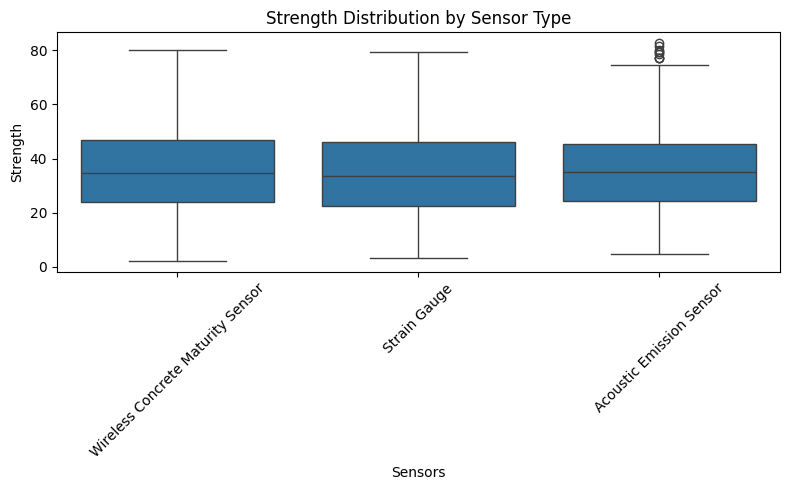

In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, pearsonr
# Load dataset (replace with your actual file path or variable)
df_val = pd.read_csv('ConcreteVal.csv')

# Summary statistics for each sensor
sensor_stats = df_val.groupby('Sensors')['Strength'].describe()
print("Sensor-Based Strength Statistics:\n", sensor_stats)

# ANOVA test to see if sensor types significantly affect strength
groups = [group['Strength'].values for name, group in df_val.groupby('Sensors')]
f_stat, p_val = f_oneway(*groups)
print("\nANOVA F-statistic:", f_stat)
print("p-value:", p_val)

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_val, x='Sensors', y='Strength')
plt.title('Strength Distribution by Sensor Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Material Sensitivity (Correlation with Strength):
              Material  Correlation  AbsCorrelation
0              Cement     0.497832        0.497832
4    Superplasticizer     0.366079        0.366079
3               Water    -0.289633        0.289633
6      Fine Aggregate    -0.167241        0.167241
5    Coarse Aggregate    -0.164935        0.164935
1  Blast Furnace Slag     0.134829        0.134829
2             Fly Ash    -0.105755        0.105755


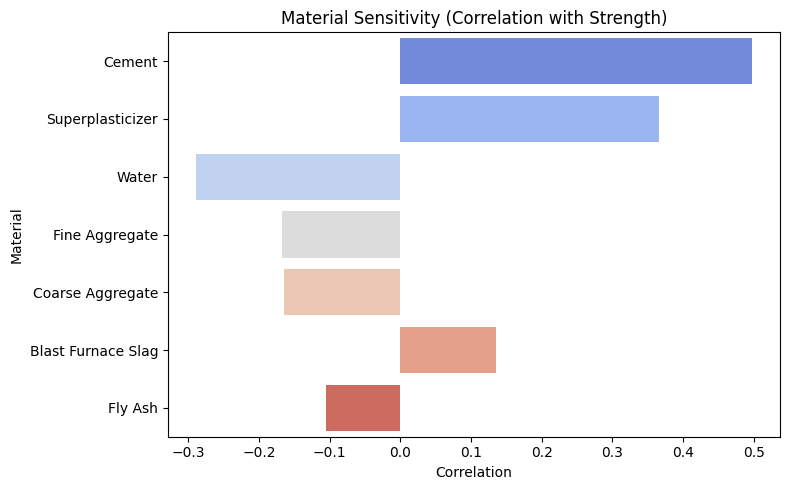

In [99]:
# Use ConcreteData or ConcreteVal
df = pd.read_csv('ConcreteData.csv')  # or ConcreteVal.csv

# Select materials and target
features = ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water',
            'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate']
correlations = {}

# Calculate Pearson correlation between each feature and Strength
for col in features:
    corr, _ = pearsonr(df[col], df['Strength'])
    correlations[col] = corr

# Convert to DataFrame
material_corr_df = pd.DataFrame(list(correlations.items()), columns=['Material', 'Correlation'])
material_corr_df['AbsCorrelation'] = material_corr_df['Correlation'].abs()
material_corr_df = material_corr_df.sort_values(by='AbsCorrelation', ascending=False)

print("Material Sensitivity (Correlation with Strength):\n", material_corr_df)

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(
    data=material_corr_df,
    x='Correlation',
    y='Material',
    hue='Material',
    dodge=False,
    legend=False,
    palette='coolwarm'
)
plt.title('Material Sensitivity (Correlation with Strength)')
plt.tight_layout()
plt.show()


Strength Stats by Age Group:
            count       mean        std    min      25%     50%      75%    max
AgeGroup                                                                      
<7 days    262.0  22.308397  12.853688   2.33  12.6625  18.520  30.2450  59.09
7–28 days  487.0  35.730431  14.328066   8.54  25.4250  33.300  43.5750  81.75
28–56       91.0  51.890220  14.308545  23.25  39.4300  51.720  62.6950  80.20
56–90       54.0  40.480370   9.819174  21.86  32.9700  39.680  47.7625  69.66
90+        136.0  49.551691  12.936121  24.10  40.5250  47.335  56.5325  82.60


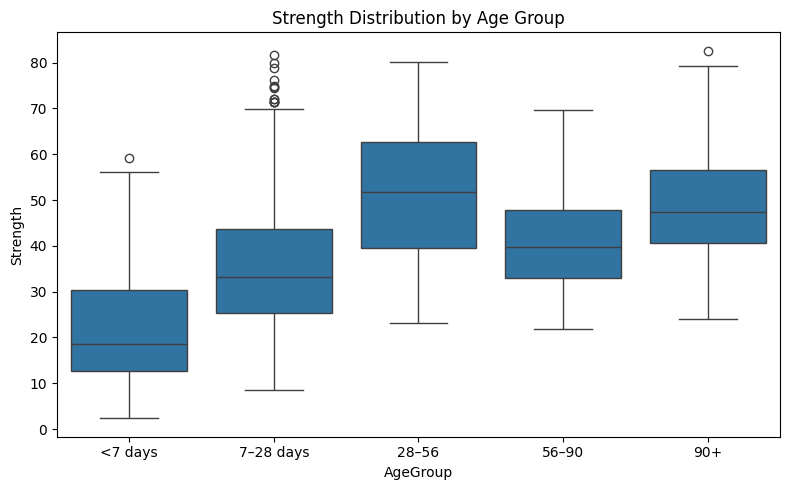


Pearson Correlation (Age vs Strength): 0.3289


In [100]:
# Histogram by age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 7, 28, 56, 90, 365],
                        labels=['<7 days', '7–28 days', '28–56', '56–90', '90+'])

grouped = df.groupby('AgeGroup', observed=False)['Strength'].describe()
print("Strength Stats by Age Group:\n", grouped)

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='AgeGroup', y='Strength', order=['<7 days', '7–28 days', '28–56', '56–90', '90+'])
plt.title('Strength Distribution by Age Group')
plt.tight_layout()
plt.show()

# Pearson correlation for numeric analysis
corr_age, _ = pearsonr(df['Age'], df['Strength'])
print(f"\nPearson Correlation (Age vs Strength): {corr_age:.4f}")


Chi-square value: 2.5795527909332105
Degrees of freedom: 4
P-value: 0.6304494970864043
No significant relationship between Sensor type and Strength category.



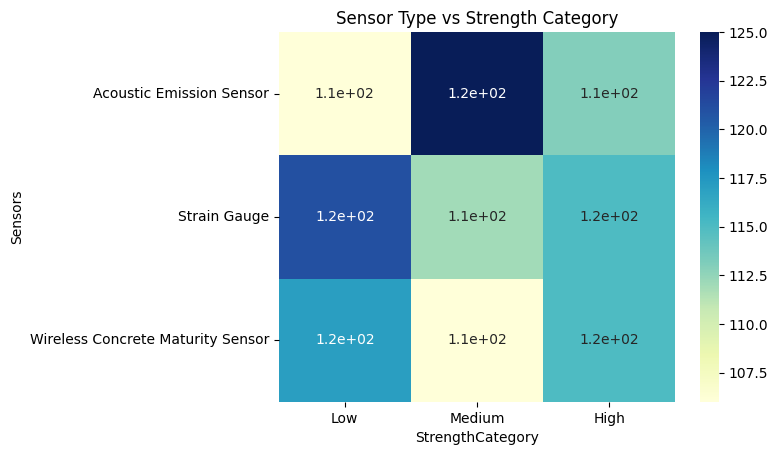

In [101]:
#CHI SQUARE TEST - STRENGTH
# Step 1: Import libraries
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load the dataset with Sensors
df = pd.read_csv('/content/ConcreteVal.csv')

# Step 3: Create strength categories (3 bins)
df['StrengthCategory'] = pd.qcut(df['Strength'], q=3, labels=['Low', 'Medium', 'High'])

# Step 4: Create contingency table
contingency = pd.crosstab(df['Sensors'], df['StrengthCategory'])

# Step 5: Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency)

# Step 6: Display results
print("Chi-square value:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)

if p < 0.05:
    print("✅ There is a significant relationship between Sensor type and Strength category.")
else:
    print("No significant relationship between Sensor type and Strength category.\n")

# Step 7: Optional visualization
sns.heatmap(contingency, annot=True, cmap='YlGnBu')
plt.title('Sensor Type vs Strength Category')
plt.show()


AgeCategory
Standard    487
Early       262
Mature      145
Aged        136
Name: count, dtype: int64

📊 Chi-Square Test: Sensors vs Age Category
Chi-square value: 8.021371984378469
Degrees of freedom: 6
P-value: 0.23654171856720912
No significant relationship between Sensor type and Age category.



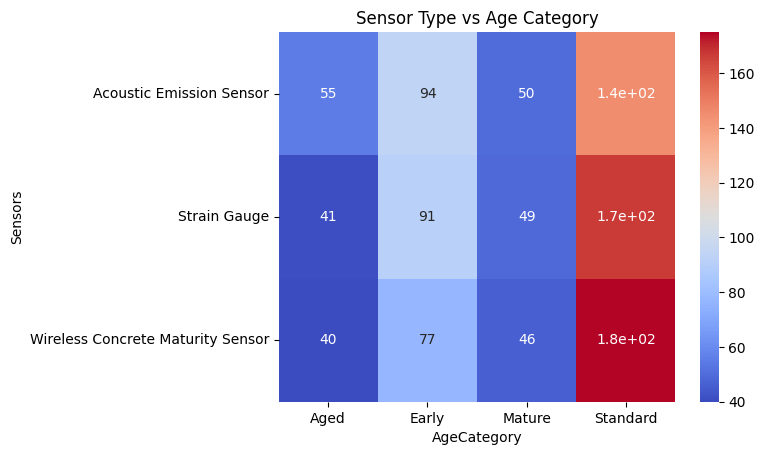

In [102]:
#CHI SQUARE TEST - AGE

import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/ConcreteVal.csv')

# Strength Binning (Quantile-based)
df['StrengthCategory'] = pd.qcut(df['Strength'], q=3, labels=['Low', 'Medium', 'High'])

# Realistic Age Labeling Function
def label_age(days):
    if days <= 7:
        return 'Early'
    elif days <= 28:
        return 'Standard'
    elif days <= 90:
        return 'Mature'
    else:
        return 'Aged'

df['AgeCategory'] = df['Age'].apply(label_age)

# View sample distribution
print(df['AgeCategory'].value_counts())

# Chi-Square Test: Sensors vs Age Category
contingency_age = pd.crosstab(df['Sensors'], df['AgeCategory'])
chi2_age, p_age, dof_age, _ = chi2_contingency(contingency_age)

# Results
print("\n📊 Chi-Square Test: Sensors vs Age Category")
print("Chi-square value:", chi2_age)
print("Degrees of freedom:", dof_age)
print("P-value:", p_age)

if p_age < 0.05:
    print("There is a significant relationship between Sensor type and Age category.")
else:
    print("No significant relationship between Sensor type and Age category.\n")

# Heatmap (Optional Visualization)
sns.heatmap(contingency_age, annot=True, cmap='coolwarm')
plt.title('Sensor Type vs Age Category')
plt.show()


🔬 ANOVA: Strength vs Sensors
F-statistic: 0.18681033788161067
P-value: 0.8296292493673156
No significant difference in Strength between Sensors.


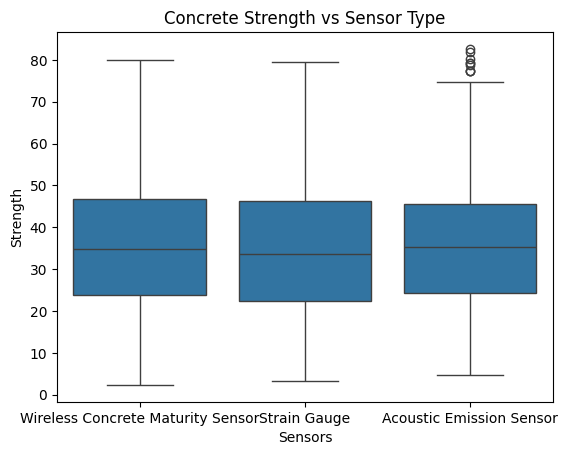


🔬 ANOVA: Strength vs Age Category
F-statistic: 165.73927385736778
P-value: 1.3405291256155715e-87
Significant difference in Strength between Age Categories.


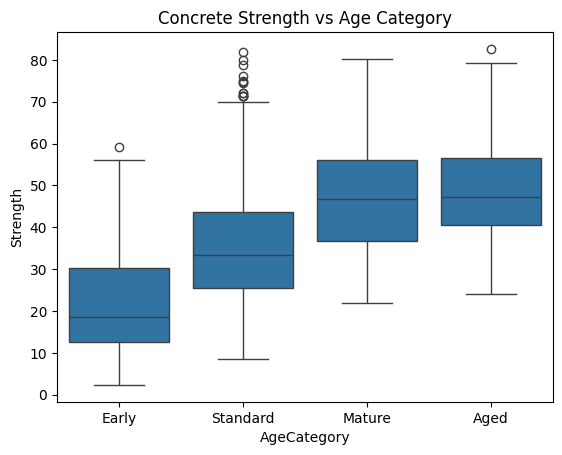

In [103]:
#ANOVA - AGE AND STRENGTH VS SENSOR
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Load dataset
df = pd.read_csv('/content/ConcreteVal.csv')

# Label Age Categories (realistic)
def label_age(days):
    if days <= 7:
        return 'Early'
    elif days <= 28:
        return 'Standard'
    elif days <= 90:
        return 'Mature'
    else:
        return 'Aged'

df['AgeCategory'] = df['Age'].apply(label_age)

# -------- ANOVA: Strength vs Sensors --------
sensor_groups = [group["Strength"].values for name, group in df.groupby("Sensors")]
f_stat_sensors, p_val_sensors = f_oneway(*sensor_groups)

print("🔬 ANOVA: Strength vs Sensors")
print("F-statistic:", f_stat_sensors)
print("P-value:", p_val_sensors)
if p_val_sensors < 0.05:
    print("Significant difference in Strength between Sensors.")
else:
    print("No significant difference in Strength between Sensors.")

# Boxplot for visualization
sns.boxplot(x='Sensors', y='Strength', data=df)
plt.title("Concrete Strength vs Sensor Type")
plt.show()

# -------- ANOVA: Strength vs Age Category --------
age_groups = [group["Strength"].values for name, group in df.groupby("AgeCategory")]
f_stat_age, p_val_age = f_oneway(*age_groups)

print("\n🔬 ANOVA: Strength vs Age Category")
print("F-statistic:", f_stat_age)
print("P-value:", p_val_age)
if p_val_age < 0.05:
    print("Significant difference in Strength between Age Categories.")
else:
    print("No significant difference in Strength between Age Categories.")

# Boxplot for visualization
sns.boxplot(x='AgeCategory', y='Strength', data=df, order=['Early', 'Standard', 'Mature', 'Aged'])
plt.title("Concrete Strength vs Age Category")
plt.show()


In [104]:
#RFE
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

# Load dataset
df = pd.read_csv('/content/ConcreteData.csv')

# Features and target
X = df.drop('Strength', axis=1)
y = df['Strength']

# Model
model = LinearRegression()

# RFE setup: choose how many features to select
rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X, y)

# Output results
print("Feature Ranking (1 = most important):")
for feature, rank in zip(X.columns, rfe.ranking_):
    print(f"{feature}: Rank {rank}")

print("\nSelected Top 5 Features:")
print(X.columns[rfe.support_])


Feature Ranking (1 = most important):
Cement: Rank 1
Blast Furnace Slag: Rank 1
Fly Ash: Rank 2
Water: Rank 1
Superplasticizer: Rank 1
Coarse Aggregate: Rank 4
Fine Aggregate: Rank 3
Age: Rank 1

Selected Top 5 Features:
Index(['Cement', 'Blast Furnace Slag', 'Water', 'Superplasticizer', 'Age'], dtype='object')


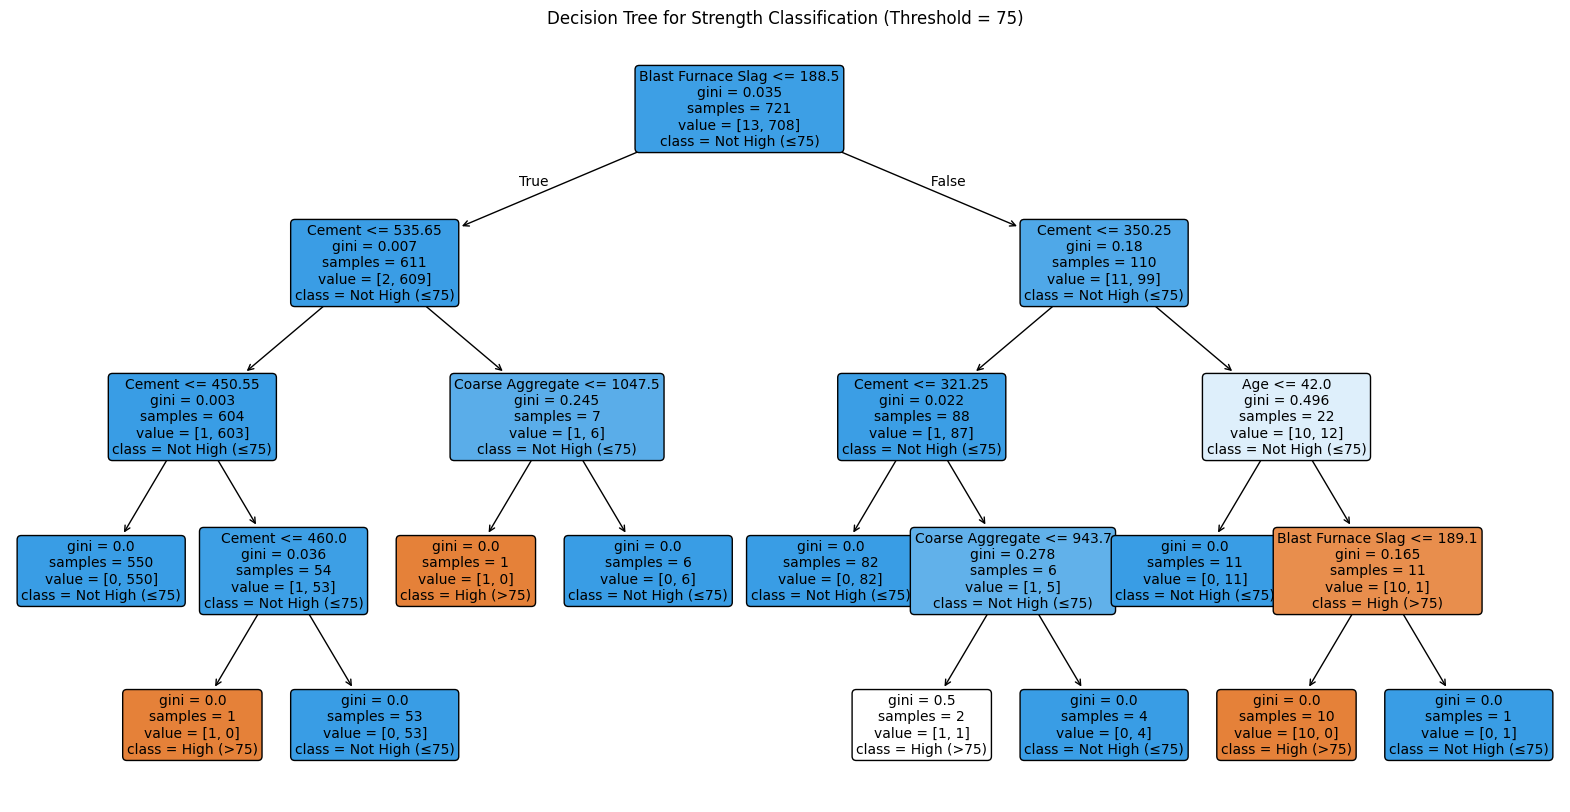

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

df = pd.read_csv("ConcreteVal.csv")

# Define binary target: High if Strength > 75
threshold = 75
df['StrengthLabel'] = df['Strength'].apply(lambda x: 'High (>75)' if x > threshold else 'Not High (≤75)')

# Define features and target
X = df.drop(columns=['Strength', 'StrengthLabel', 'Sensors'])
y = df['StrengthLabel']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Decision Tree
model = DecisionTreeClassifier(max_depth=4, random_state=42)  # Limit depth for clarity
model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,  # ['High (>75)', 'Not High (≤75)']
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree for Strength Classification (Threshold = 75)')
plt.show()


=== ID3 (Classification) ===

Confusion Matrix:
 [[40  0 31]
 [ 1 49 16]
 [ 9  7 53]]

Classification Report:
               precision    recall  f1-score   support

        High       0.80      0.56      0.66        71
         Low       0.88      0.74      0.80        66
      Medium       0.53      0.77      0.63        69

    accuracy                           0.69       206
   macro avg       0.73      0.69      0.70       206
weighted avg       0.73      0.69      0.70       206



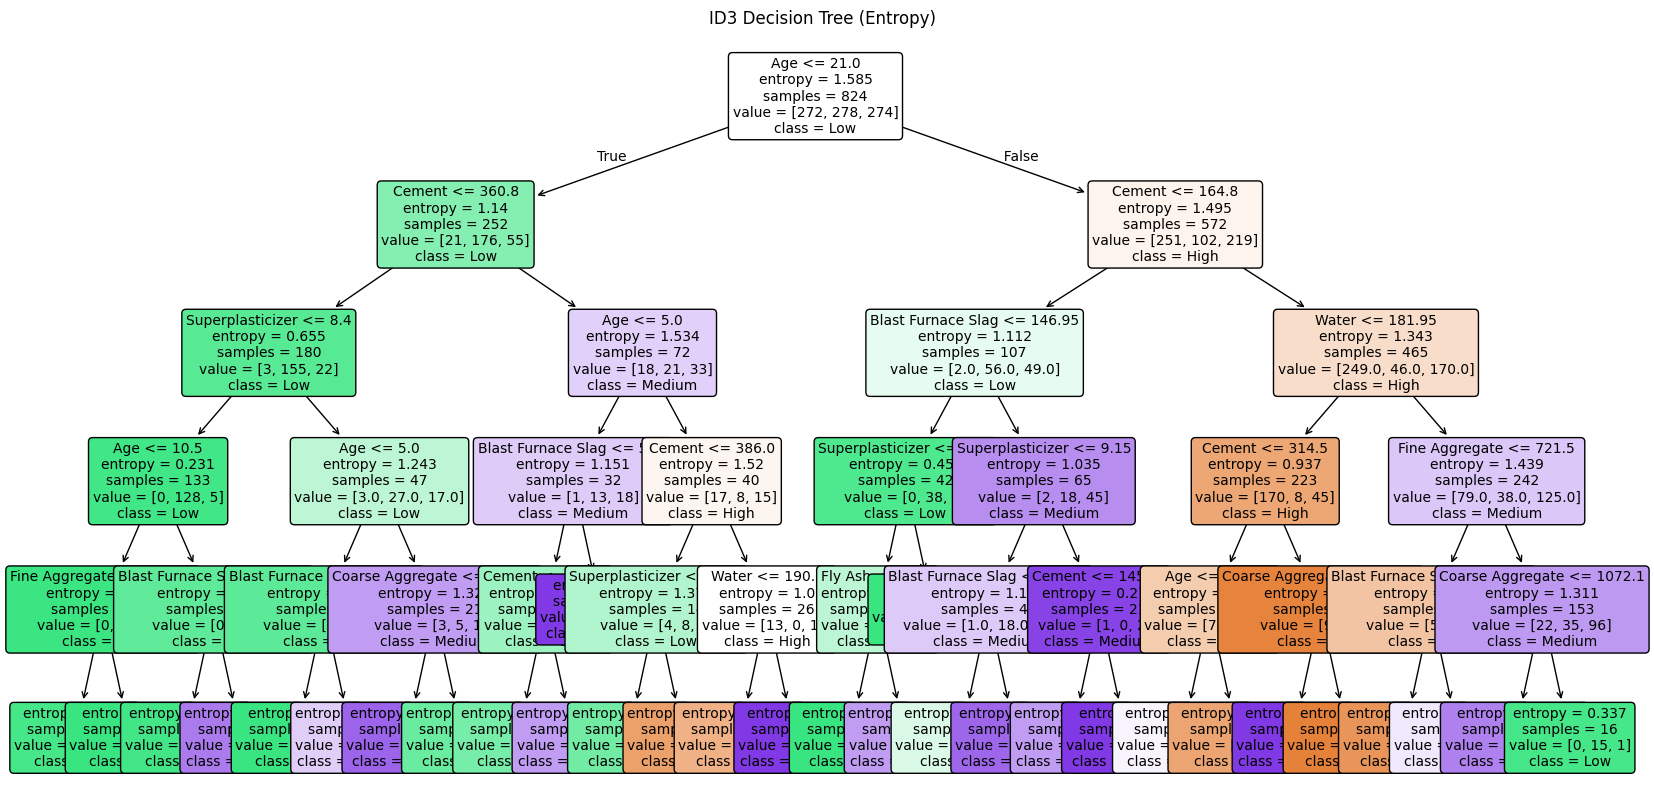

In [135]:
#ID3
import pandas as pd

df = pd.read_csv('/content/ConcreteData.csv')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Discretize Strength into 3 classes
df['Strength_Category'] = pd.qcut(df['Strength'], q=3, labels=['Low', 'Medium', 'High'])

# Features and target
X = df.drop(columns=['Strength', 'Strength_Category'])
y = df['Strength_Category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ID3 Decision Tree (uses 'entropy')
id3_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
id3_model.fit(X_train, y_train)

# Predict & Evaluate
y_pred = id3_model.predict(X_test)

print("=== ID3 (Classification) ===")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Set plot size
plt.figure(figsize=(20, 10))

# Plot the ID3 tree (classification tree)
plot_tree(id3_model,
          feature_names=X.columns,
          class_names=id3_model.classes_,
          filled=True,
          rounded=True,
          fontsize=10)

# Show the plot
plt.title("ID3 Decision Tree (Entropy)")
plt.show()


Confusion Matrix:
[[  0   0   4   0]
 [  0 133   7  15]
 [  1  16  39   0]
 [  0  11   0  83]]

Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         4
         Low       0.83      0.86      0.84       155
      Medium       0.78      0.70      0.74        56
    Very Low       0.85      0.88      0.86        94

    accuracy                           0.83       309
   macro avg       0.61      0.61      0.61       309
weighted avg       0.82      0.83      0.82       309



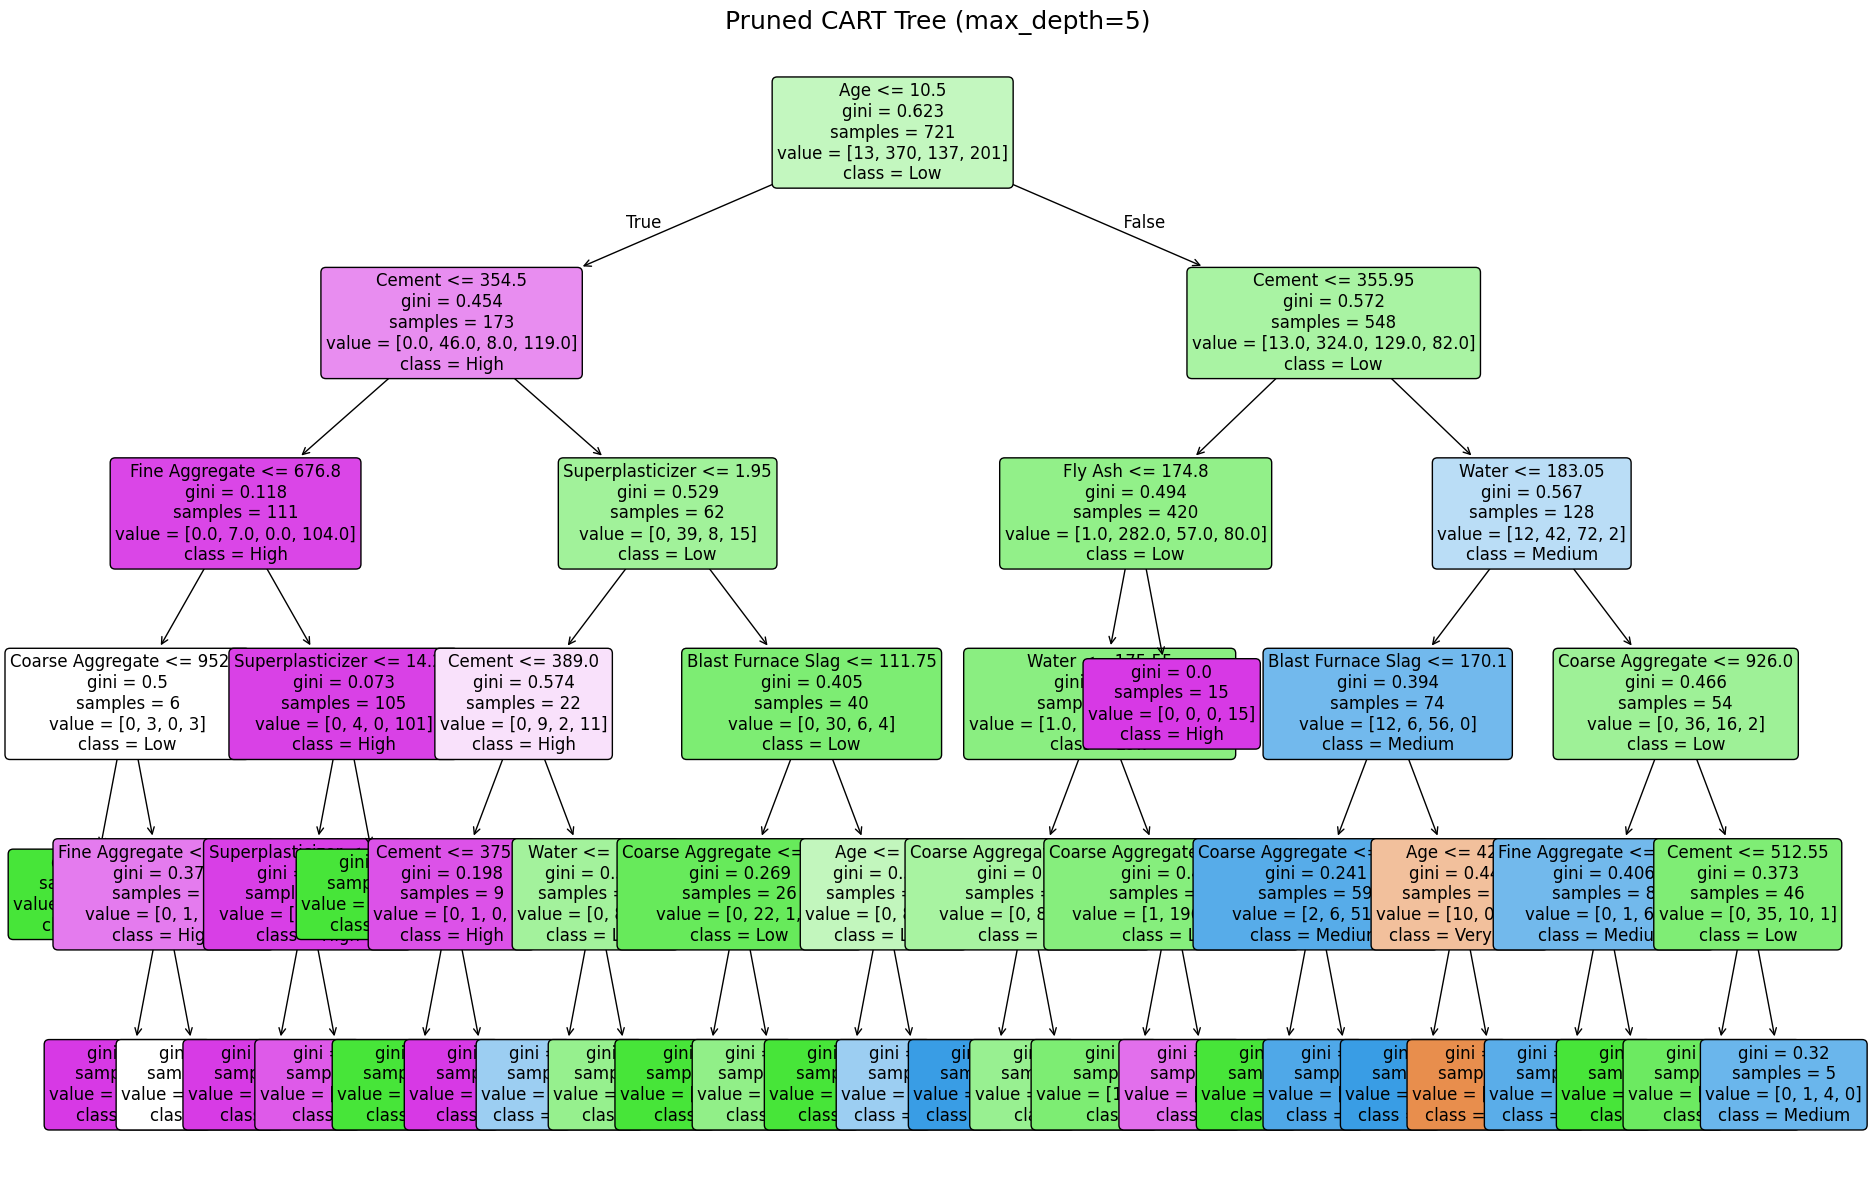

In [106]:
#CART
# Required Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Load the Dataset
df = pd.read_csv('/content/ConcreteVal.csv')  # Use your file path

# Drop the Sensors column
df = df.drop(columns=['Sensors'])

# 🏷️ Label Strength into 4 categories
bins = [2.33, 25, 50, 75, 82.6]
labels = ['Very Low', 'Low', 'Medium', 'High']
df['Strength_Label'] = pd.cut(df['Strength'], bins=bins, labels=labels, include_lowest=True)

# Define Features and Target
X = df.drop(columns=['Strength', 'Strength_Label'])
y = df['Strength_Label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 🌲 CART Model (Gini Index)
cart_model = DecisionTreeClassifier(criterion='gini', random_state=42)
cart_model.fit(X_train, y_train)

# Predict & Evaluate
y_pred = cart_model.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cart_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
cart_model.fit(X_train, y_train)

# Visualize the Tree
plt.figure(figsize=(19,12))  # Adjust size as needed
plot_tree(
    cart_model,
    feature_names=X.columns,
    class_names=labels,
    filled=True,
    rounded=True,
    fontsize=12  # Bigger font for readability
)
plt.title("Pruned CART Tree (max_depth=5)", fontsize=18)
plt.tight_layout()
plt.show()

Confusion Matrix:
[[ 16  11   0   0]
 [  1  47  33   0]
 [  0  10 121   4]
 [  0   0   8  58]]

Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.59      0.73        27
         Low       0.69      0.58      0.63        81
      Medium       0.75      0.90      0.81       135
    Very Low       0.94      0.88      0.91        66

    accuracy                           0.78       309
   macro avg       0.83      0.74      0.77       309
weighted avg       0.79      0.78      0.78       309



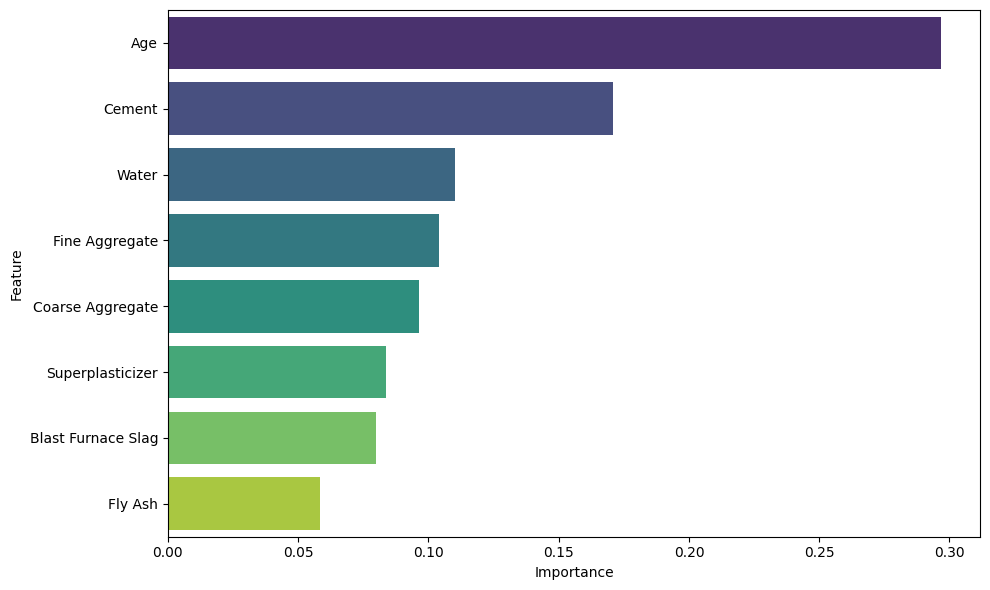

In [134]:
#RANDOM FOREST

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load your dataset
data = pd.read_csv("ConcreteVal.csv")

# Step 1: Create StrengthCategory from continuous 'Strength'
# You can customize the bins and labels
data['StrengthCategory'] = pd.cut(
    data['Strength'],
    bins=[0, 20, 40, 60, 100],  # Adjust based on your data range
    labels=['Very Low', 'Medium', 'Low', 'High']
)

# Step 2: Drop the original Strength column
X = data.drop(['Strength', 'StrengthCategory', 'Sensors'], axis=1)
y = data['StrengthCategory']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 4: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Step 5: Predictions
y_pred = rf_model.predict(X_test)

# Step 6: Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Feature Importance Bar Plot
importances = rf_model.feature_importances_
features = X.columns
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, hue='Feature', dodge=False, legend=False, palette='viridis')
plt.tight_layout()
plt.show()

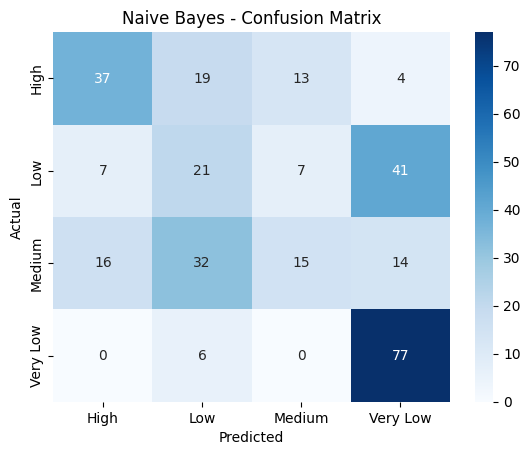

Classification Report:
              precision    recall  f1-score   support

        High       0.62      0.51      0.56        73
         Low       0.27      0.28      0.27        76
      Medium       0.43      0.19      0.27        77
    Very Low       0.57      0.93      0.70        83

    accuracy                           0.49       309
   macro avg       0.47      0.48      0.45       309
weighted avg       0.47      0.49      0.45       309



In [107]:
#NAIVE BAYES

# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load dataset
df = pd.read_csv('/content/ConcreteVal.csv')

# Step 3: Create StrengthCategory (4 classes based on quantiles)
df['StrengthCategory'] = pd.qcut(df['Strength'], q=4, labels=['Very Low', 'Low', 'Medium', 'High'])

# 🧹 Step 4: Prepare features (exclude Strength & Sensors)
X = df.drop(['Strength', 'Sensors', 'StrengthCategory'], axis=1)
y = df['StrengthCategory']

# Step 5: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 6: Train Naive Bayes classifier
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Step 7: Predictions and Evaluation
y_pred = nb_model.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))



--- Simple Linear Regression: Strength ~ Cement ---
Intercept: 13.7852
Coefficient for Cement: 0.0779
Mean Squared Error: 192.7848
R² Score: 0.2518


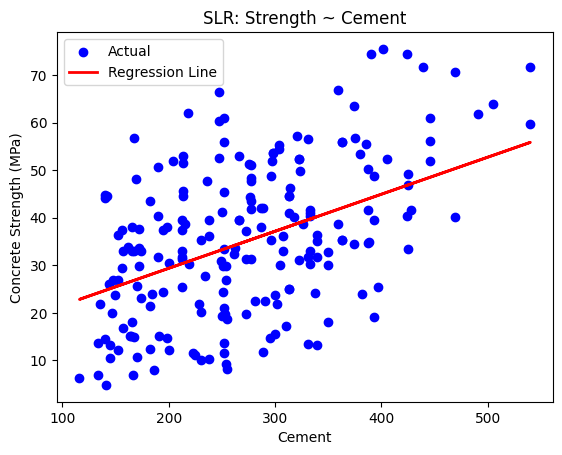


--- Simple Linear Regression: Strength ~ Water ---
Intercept: 76.7811
Coefficient for Water: -0.2251
Mean Squared Error: 232.8466
R² Score: 0.0964


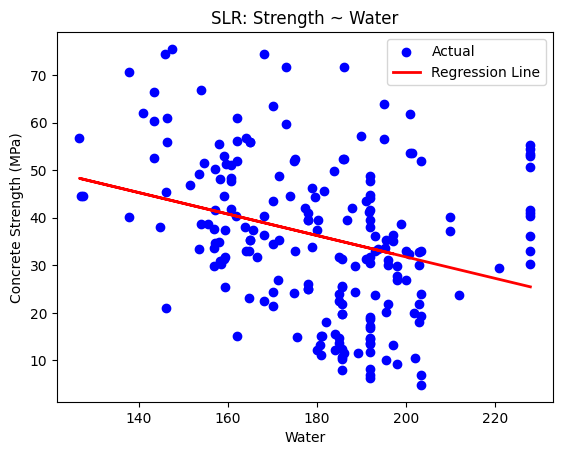


--- Simple Linear Regression: Strength ~ Age ---
Intercept: 31.7219
Coefficient for Age: 0.0926
Mean Squared Error: 232.9604
R² Score: 0.0959


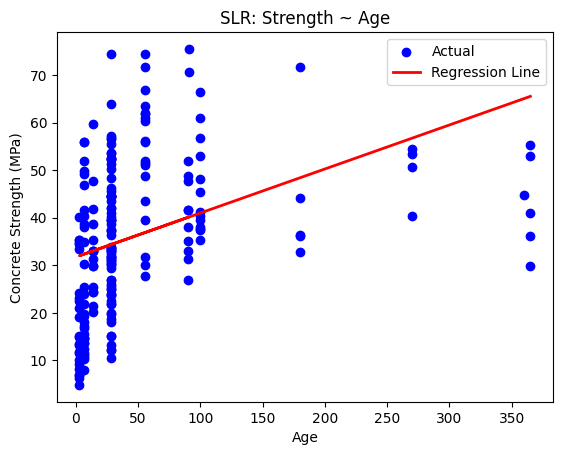

In [109]:
#LINEAR REGRESSION
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = pd.read_csv('ConcreteData.csv')

# List of independent variables to try
variables = ['Cement', 'Water', 'Age']

for var in variables:
    print(f"\n--- Simple Linear Regression: Strength ~ {var} ---")

    # Prepare data
    X = data[[var]]
    y = data['Strength']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    print(f"Intercept: {model.intercept_:.4f}")
    print(f"Coefficient for {var}: {model.coef_[0]:.4f}")
    print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

    # Plot
    plt.scatter(X_test, y_test, color='blue', label='Actual')
    plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
    plt.xlabel(f'{var}')
    plt.ylabel('Concrete Strength (MPa)')
    plt.title(f'SLR: Strength ~ {var}')
    plt.legend()
    plt.show()



--- Multivariate Linear Regression Coefficients ---
           Feature  Coefficient
         Intercept   -28.823555
            Cement     0.118994
Blast Furnace Slag     0.108536
           Fly Ash     0.082152
             Water    -0.135276
  Superplasticizer     0.310570
  Coarse Aggregate     0.017867
    Fine Aggregate     0.024100
               Age     0.116439

--- Model Evaluation ---
Mean Squared Error (MSE): 95.9709
R² Score: 0.6276



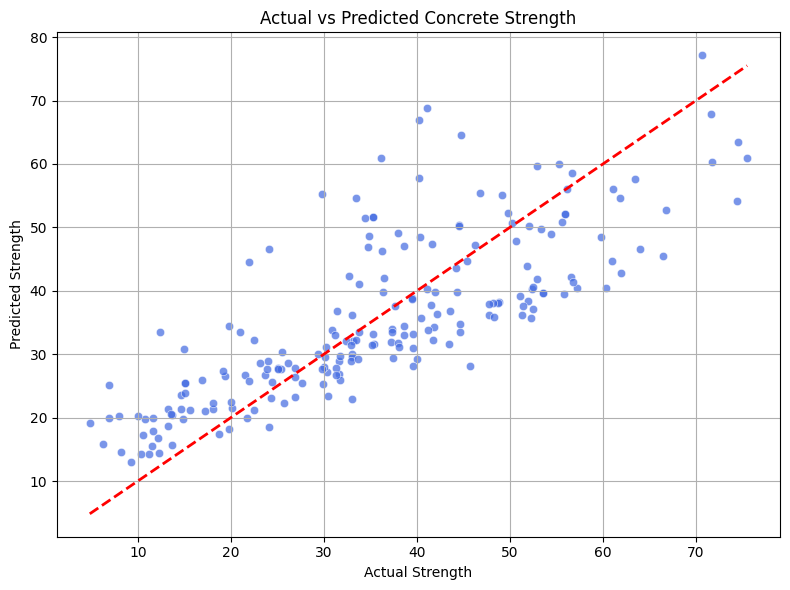

In [110]:
#MULTIVARIATE REGRESSION
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
data = pd.read_csv('ConcreteData.csv')

# Step 2: Separate features and target
X = data.drop(['Strength'], axis=1)
y = data['Strength']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Fit Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Step 6: Print coefficients in tabular format
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
coeff_df.loc[-1] = ['Intercept', model.intercept_]
coeff_df.index = coeff_df.index + 1
coeff_df = coeff_df.sort_index()

# Step 7: Display
print("\n--- Multivariate Linear Regression Coefficients ---")
print(coeff_df.to_string(index=False))

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}\n")


y_pred = model.predict(X_test)

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='royalblue', alpha=0.7)

# Add diagonal reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)

plt.title("Actual vs Predicted Concrete Strength")
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.grid(True)
plt.tight_layout()
plt.show()

In [111]:
import pandas as pd

# Load the dataset
file_path = '/content/ConcreteData.csv'
df = pd.read_csv(file_path)

# Drop duplicates (as we discussed)
df = df.drop_duplicates()

# Preview the dataset
df.head()


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [112]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Strength', axis=1)
y = df['Strength']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


In [113]:
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [114]:
from sklearn.decomposition import PCA

# Initialize PCA and fit to the scaled data
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Check explained variance
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[0.29476751 0.17822875 0.15975621 0.12842832 0.11787365 0.09498269
 0.02216116 0.00380172]


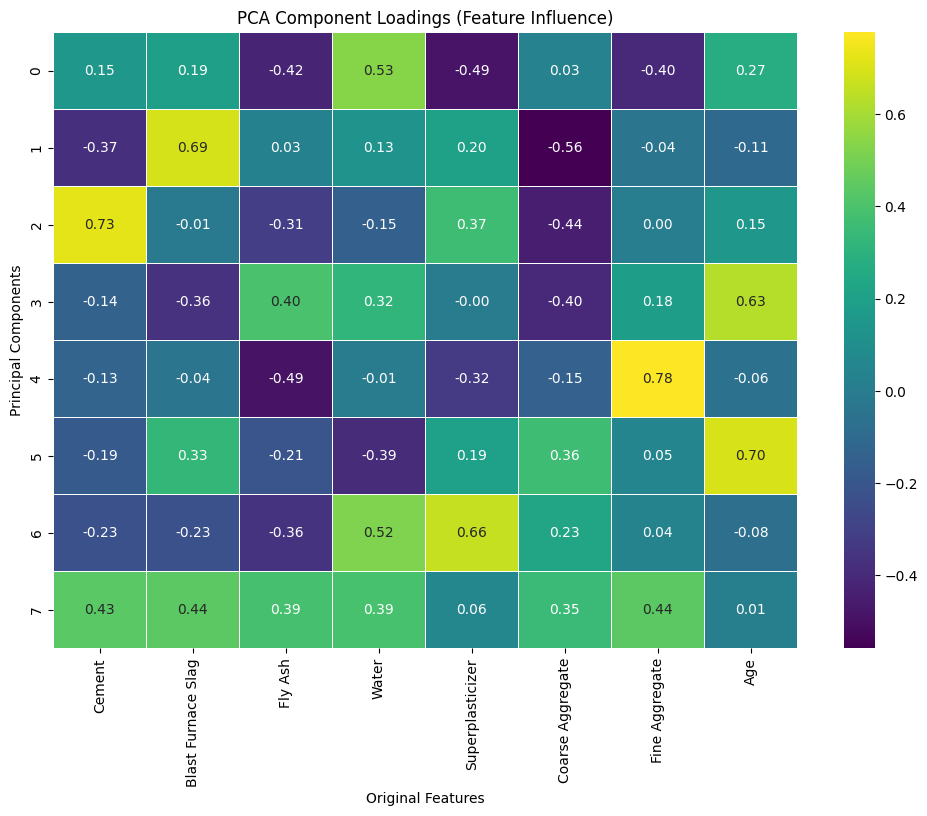

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame of PCA component loadings
pca_components_df = pd.DataFrame(pca.components_, columns=X.columns)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pca_components_df, cmap='viridis', annot=True, fmt=".2f", linewidths=0.5)
plt.xlabel('Original Features')
plt.ylabel('Principal Components')
plt.title('PCA Component Loadings (Feature Influence)')
plt.show()


  * PC1 is heavily influenced by Blast Furnace Slag.
  * PC4 is heavily influenced by Fine Aggregate.
  * PC2 is influenced by Cement.
  * PC5 is linked to Age.
  
Strength is driven by cement content and curing age (which makes sense in real life). Other features (like fine aggregate) contribute less directly.

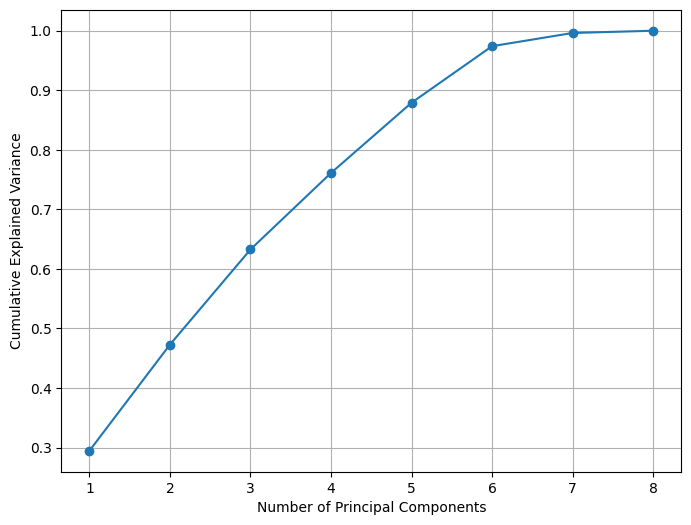

In [116]:
import matplotlib.pyplot as plt

# Plot explained variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance.cumsum(), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()


This shows how much variance is captured as we add more principal components.


*   Steep slope: The first few components capture a lot of information.
*   Plateau: After a certain number of components, adding more doesn’t contribute much new information.

Inference:
If the plot flattens around 3–4 components (say 95% variance), we can reduce dimensionality to those components without losing much information.

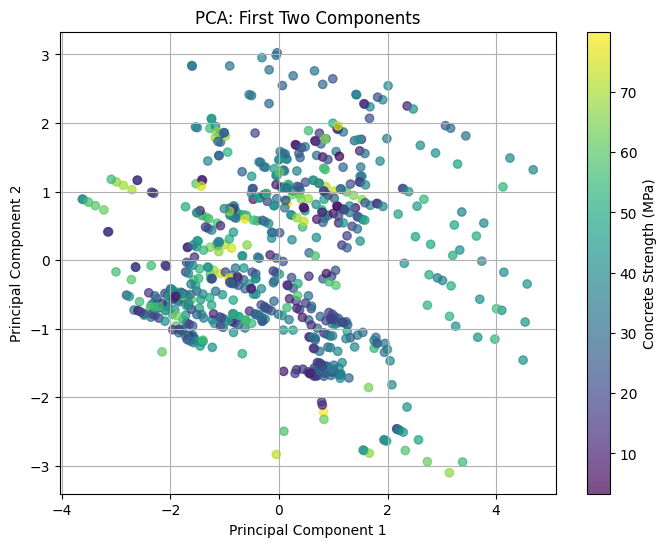

In [117]:
# Scatter plot of the first two components
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Concrete Strength (MPa)')
plt.title('PCA: First Two Components')
plt.grid()
plt.show()


This shows how our data points are distributed in the space defined by the top 2 components.

*   Clusters: Points forming tight clusters may represent distinct groups of concrete mixes with similar properties (e.g., similar strength or age).
*    Gradient Colors: If color represents strength, a smooth color gradient suggests the components correlate well with strength.



Inference:
If points spread out linearly, our data might be well-suited to simple linear models.
If there are overlapping clusters, predicting strength might be harder, suggesting complex interactions between features.

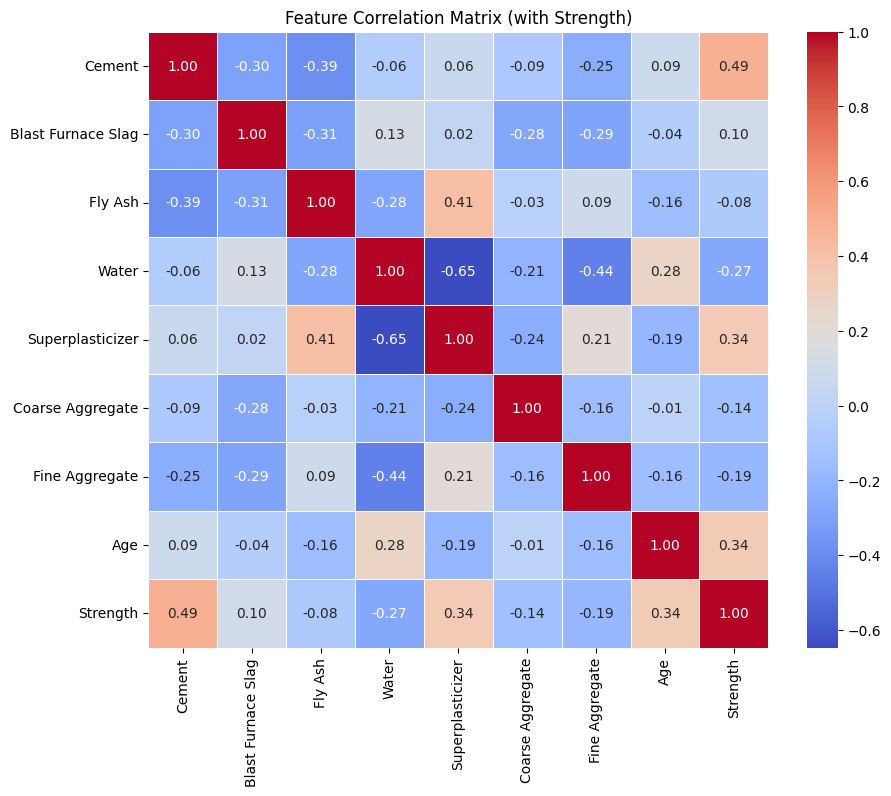

In [118]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot a heatmap of the correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix (with Strength)')
plt.show()


In [119]:
# Step 1: Train-Test split on raw features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Apply PCA on training set and transform both
from sklearn.decomposition import PCA

pca = PCA(n_components=5)  # Or however many components you need
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)  # Use .transform, not .fit_transform

In [120]:
#KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the KNN model
knn = KNeighborsRegressor(n_neighbors=5)  # You can experiment with n_neighbors
knn.fit(X_train_pca, y_train)

# Make predictions
y_pred = knn.predict(X_test_pca)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')


Mean Squared Error: 98.92085289552239
R² Score: 0.6684123372416872


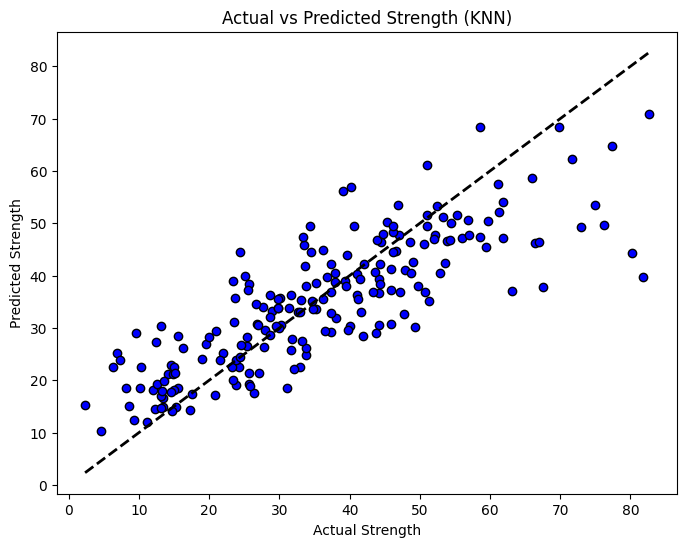

In [121]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Strength')
plt.ylabel('Predicted Strength')
plt.title('Actual vs Predicted Strength (KNN)')
plt.show()


In [122]:
# Define features and target
X_original = df.drop(columns=['Strength'])  # Use original features
y = df['Strength']  # Strength is the target feature

# Split the data
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X_original, y, test_size=0.2, random_state=42)


In [123]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training data, and transform the test data
X_train_orig = scaler.fit_transform(X_train_orig)
X_test_orig = scaler.transform(X_test_orig)


In [124]:
# Initialize and train the KNN regressor
knn_orig = KNeighborsRegressor(n_neighbors=5)  # Start with k=5
knn_orig.fit(X_train_orig, y_train)


KNeighborsRegressor()

In [125]:
# Predict strength on the test set
y_pred_orig = knn_orig.predict(X_test_orig)


In [126]:
# Calculate evaluation metrics
mse_orig = mean_squared_error(y_test, y_pred_orig)
r2_orig = r2_score(y_test, y_pred_orig)

# Print the results
print(f'Mean Squared Error (Original Features): {mse_orig:.2f}')
print(f'R² Score (Original Features): {r2_orig:.2f}')


Mean Squared Error (Original Features): 84.50
R² Score (Original Features): 0.72


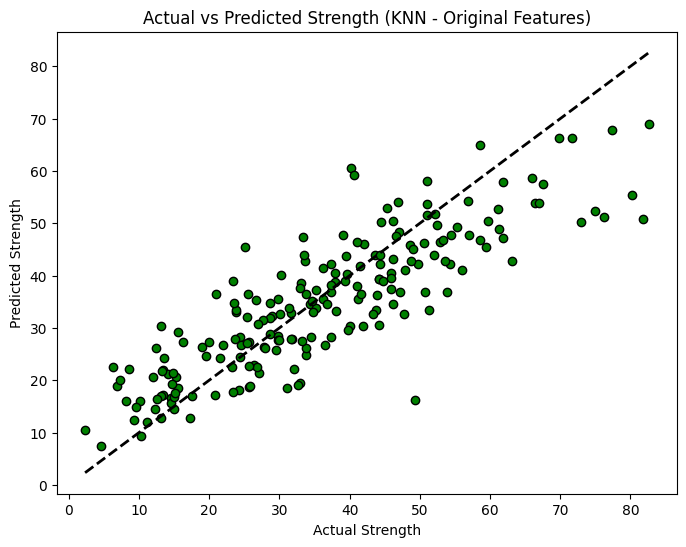

In [127]:
# Plot actual vs predicted strength
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_orig, color='green', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Strength')
plt.ylabel('Predicted Strength')
plt.title('Actual vs Predicted Strength (KNN - Original Features)')
plt.show()


Original features perform better for prediction because:
Strength is physically dependent on the raw materials and curing time. PCA abstracts the features into components, but some feature-specific details get lost.The original features are already well-structured and predictions are more accurate